# Stage 1: Exploratory Data Analysis (EDA) - Spotify Tracks Dataset

**Objective:** Audit data integrity, analyze acoustic distributions, evaluate correlations, and explore patterns across categorical and temporal features.

In [16]:
# 1. Imports and Global Plotting Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual Configurations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

## 1. Data Ingestion & Structural Audit

In [17]:
# 2. Data Ingestion
df = pd.read_csv('../data/spotify_data_processed.csv')

df.head()

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label,release_year,release_month,release_day_of_week,duration_minutes,popularity_category,loudness_category,key_name,mode_name,is_explicit_bool,release_quarter,is_weekend_release,log_stream_count,upbeat_score,artist_track_count
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.15,0.74,9,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music,2016,4,Friday,3.903233,Medium,Quiet,A,Minor,False,2,False,9.472782,0.445,1
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.44,0.46,0,-14.02,0,0.223,157.74,1000,France,1,Island Records,2022,4,Friday,6.261767,Medium,Moderate,C,Minor,True,2,False,6.908755,0.450,3
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.62,0.80,8,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings,2016,2,Tuesday,4.819850,Medium,Quiet,G#,Major,True,1,False,6.908755,0.710,2
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.78,0.98,1,-34.47,1,0.684,149.00,1000,France,0,Warner Music,2015,10,Monday,3.491400,Medium,Quiet,C#,Major,False,4,False,6.908755,0.880,4
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.74,0.18,10,-17.84,0,0.304,155.85,2000,United States,0,Independent,2022,7,Friday,2.123917,Medium,Moderate,A#,Minor,False,3,False,7.601402,0.460,2


In [18]:
# Check dataset shape (rowa, columns)
print(f"Total Records (Row): {df.shape[0]:,}")
print(f"Total Features (Columns): {df.shape[1]}")

# Display data types and memory footprint
df.info()

Total Records (Row): 85,000
Total Features (Columns): 33
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             85000 non-null  object 
 1   track_name           85000 non-null  object 
 2   artist_name          85000 non-null  object 
 3   album_name           85000 non-null  object 
 4   release_date         85000 non-null  object 
 5   genre                85000 non-null  object 
 6   duration_ms          85000 non-null  int64  
 7   popularity           85000 non-null  int64  
 8   danceability         85000 non-null  float64
 9   energy               85000 non-null  float64
 10  key                  85000 non-null  int64  
 11  loudness             85000 non-null  float64
 12  mode                 85000 non-null  int64  
 13  instrumentalness     85000 non-null  float64
 14  tempo                85000 no

## 2. Data Quality & Cleaning

In [19]:
# Identify missing values per column
missing_values = df.isnull().sum()
missing_columns = missing_values[missing_values > 0]

print("Columns with missing values:")
print(missing_columns if not missing_columns.empty else "No missing values found.")

# Identify and remove duplicate rows
duplicates_count = df.duplicated().sum()
print(f"\nTotal duplicate rows found: {duplicates_count}")

if duplicates_count > 0:
    df = df.drop_duplicates()
    print("Duplicates successfully removed.")

Columns with missing values:
No missing values found.

Total duplicate rows found: 0


In [20]:
# Generate descriptive statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_ms,85000.0,254913.824294,9.530023e+04,90004.000000,171871.500000,254920.500000,337203.250000,4.200000e+05
popularity,85000.0,48.162894,1.482975e+01,0.000000,38.000000,47.000000,57.000000,1.000000e+02
danceability,85000.0,0.520710,2.707991e-01,0.050000,0.290000,0.520000,0.760000,9.900000e-01
energy,85000.0,0.505412,2.797743e-01,0.020000,0.260000,0.500000,0.750000,9.900000e-01
key,85000.0,5.515988,3.454069e+00,0.000000,2.750000,6.000000,9.000000,1.100000e+01
loudness,85000.0,-27.999300,1.559837e+01,-55.000000,-41.470000,-27.970000,-14.500000,-1.000000e+00
mode,85000.0,0.500141,5.000029e-01,0.000000,0.000000,1.000000,1.000000,1.000000e+00
instrumentalness,85000.0,0.399781,2.314697e-01,0.000000,0.198000,0.399000,0.600000,8.000000e-01
tempo,85000.0,129.948351,4.044432e+01,60.000000,94.840000,129.990000,165.030000,2.000000e+02
stream_count,85000.0,214354.682353,1.680637e+06,1000.000000,1000.000000,2000.000000,9000.000000,2.000000e+07


## 3. Univariate & Bivariate Distribution Analysis

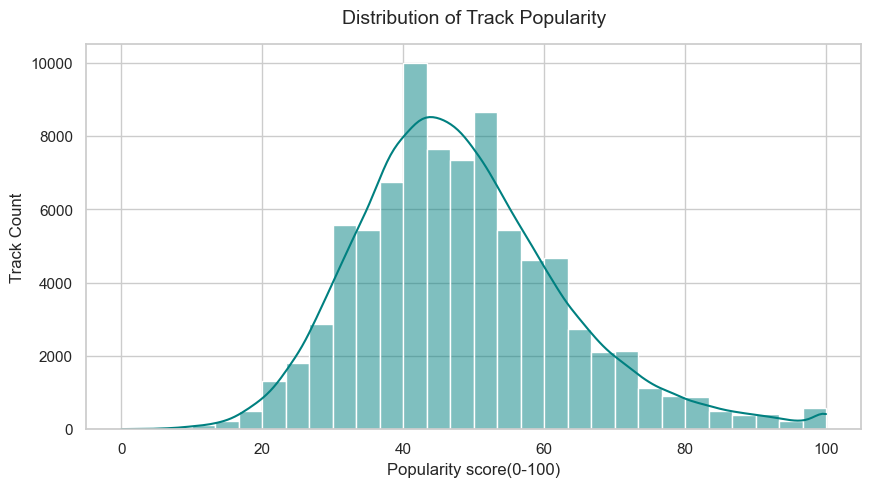

In [21]:
# Distribution of Track Popularity
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], bins=30, kde=True, color='teal')
plt.title('Distribution of Track Popularity', fontsize=14, pad=15)
plt.xlabel('Popularity score(0-100)')
plt.ylabel('Track Count')
plt.show()

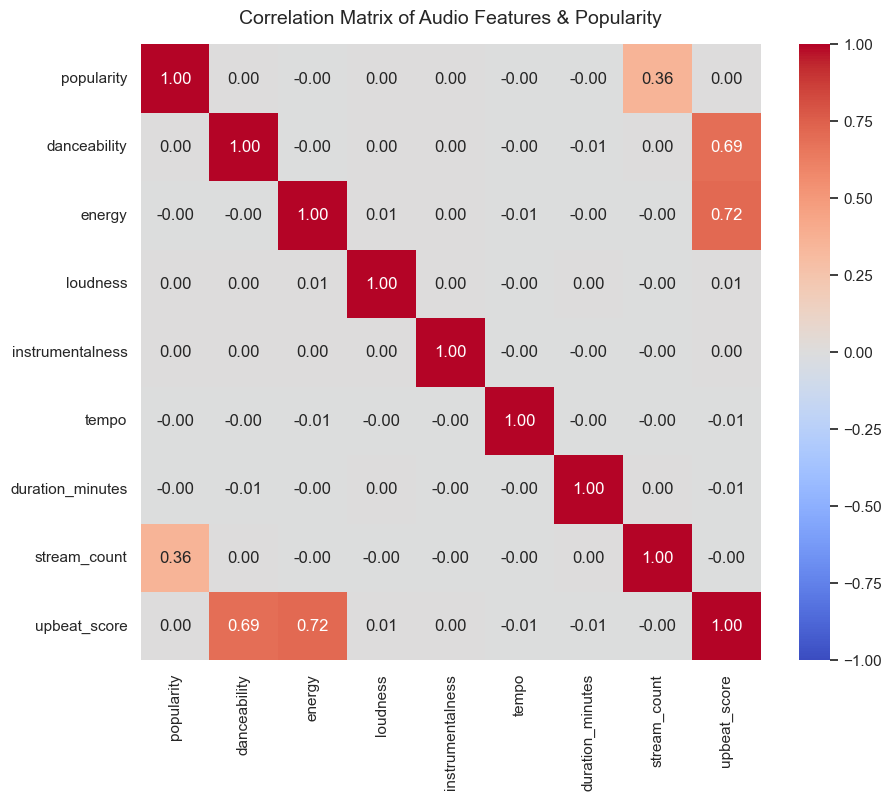

In [22]:
# Select key numerical audio features for correlation
audio_features = [
    'popularity', 'danceability', 'energy',
    'loudness', 'instrumentalness', 'tempo', 
    'duration_minutes', 'stream_count', 'upbeat_score'
]

# Calculate correlation matrix
correlation_matrix = df[audio_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Audio Features & Popularity', fontsize=14, pad=15)
plt.show()

## 4. Categorical & Content Analysis

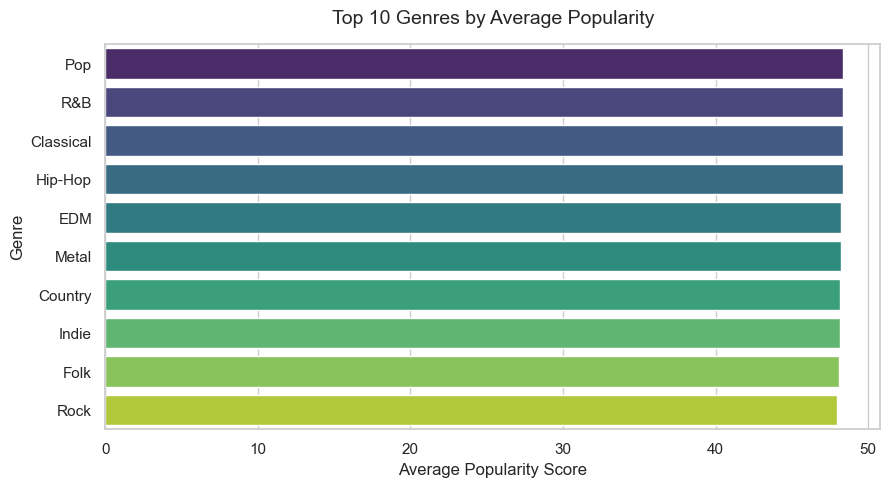

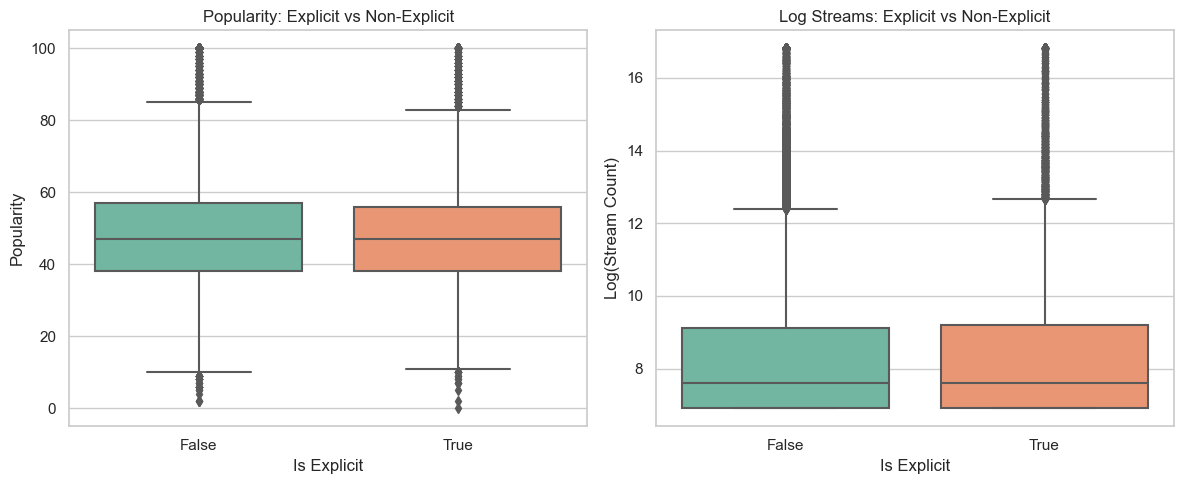

In [23]:
# 1. Top 10 Genres by Average Popularity
top_genres = (
    df.groupby('genre')['popularity']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_genres, x='popularity', y='genre', palette='viridis')
plt.title('Top 10 Genres by Average Popularity', fontsize=14, pad=15)
plt.xlabel('Average Popularity Score')
plt.ylabel('Genre')
plt.show()

# 2. Impact of Explicit Content on Popularity & Streams
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='is_explicit_bool', y='popularity', palette='Set2')
plt.title('Popularity: Explicit vs Non-Explicit', fontsize=12)
plt.xlabel('Is Explicit')
plt.ylabel('Popularity')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='is_explicit_bool', y='log_stream_count', palette='Set2')
plt.title('Log Streams: Explicit vs Non-Explicit', fontsize=12)
plt.xlabel('Is Explicit')
plt.ylabel('Log(Stream Count)')

plt.tight_layout()
plt.show()

## 5. Temporal Trends & Segmentation

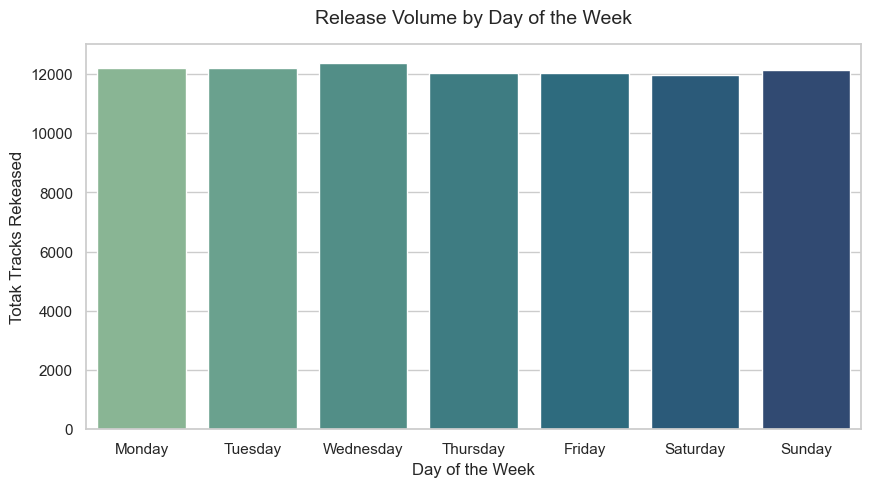

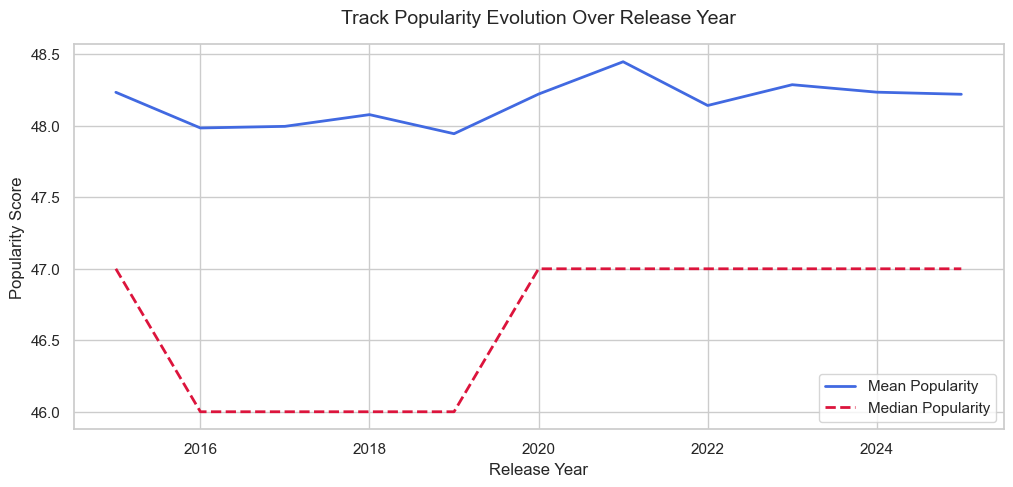

In [24]:
# 1. Distribution of releases across days of the week
plt.figure(figsize=(10, 5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='release_day_of_week', order=day_order, palette='crest')
plt.title('Release Volume by Day of the Week', fontsize=14, pad=15)
plt.xlabel('Day of the Week')
plt.ylabel('Totak Tracks Rekeased')
plt.show()

# 2. Popularity Trend by Release Year
plt.figure(figsize=(12, 5))
yearly_trend = ( 
    df.groupby('release_year')['popularity']
    .agg(['mean', 'median'])
    .reset_index()
)

sns.lineplot(data=yearly_trend, x='release_year', y='mean', label='Mean Popularity', color='royalblue', lw=2)
sns.lineplot(data=yearly_trend, x='release_year', y='median', label='Median Popularity', color='crimson', lw=2, linestyle='--')
plt.title('Track Popularity Evolution Over Release Year', fontsize=14, pad=15)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.legend()
plt.show()

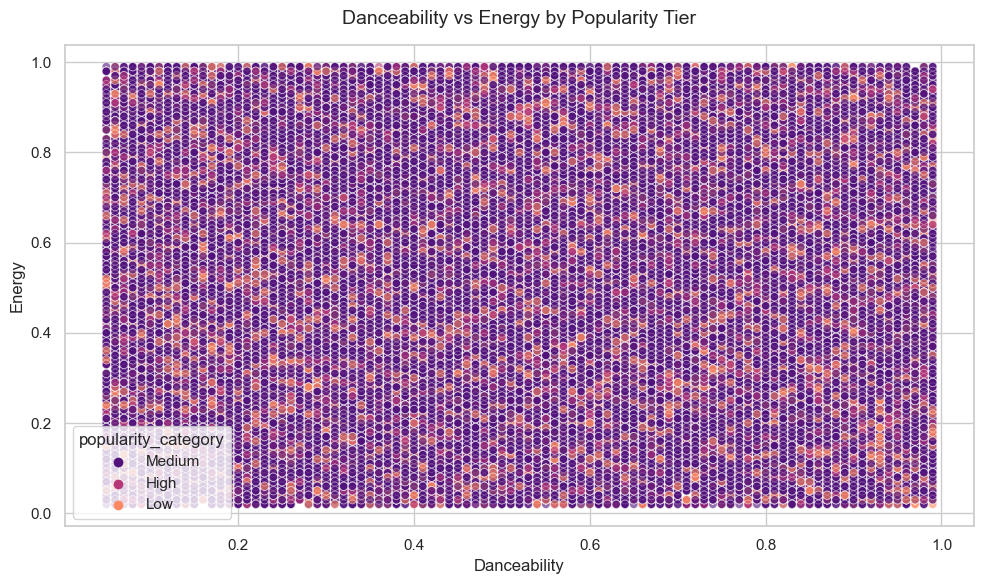

Top 10 Record Labels Performance Summary:
          label  total_tracks  avg_popularity
    Independent         10767       48.261076
       Columbia         10690       48.092984
  XL Recordings         10687       48.209507
     Sony Music         10631       48.325557
   Warner Music         10619       47.903381
            EMI         10574       48.304048
 Island Records         10527       48.003135
Universal Music         10505       48.201713


In [25]:
# 1. Scatter Plot: Energy vs Danceability colored by Popularity Category
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='danceability', y='energy', hue='popularity_category', alpha=0.6, palette='magma')
plt.title('Danceability vs Energy by Popularity Tier', fontsize=14, pad=15)
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.tight_layout()
plt.show()

# 2. Top 10 Record Labels by Track Count & Average Popularity
top_labels = (
    df.groupby('label')
    .agg(
        total_tracks=('track_id', 'count'),
        avg_popularity=('popularity', 'mean')
    )
    .sort_values(by='total_tracks', ascending=False)
    .head(10)
    .reset_index()
)

print("Top 10 Record Labels Performance Summary:")
print(top_labels.to_string(index=False))

### Key Exploratory Findings & Business Takeaways

1. **Target Distribution**: Popularity is normally distributed with a mean of ~48.2 and concentrated between 40–55 points.
2. **Audio Features vs Popularity**: Individual acoustic features (danceability, energy, tempo, loudness) exhibit near-zero linear correlation with popularity scores.
3. **Stream Volume Relationship**: Track streams (`stream_count`) display a moderate positive correlation (0.36) with popularity.
4. **Metadata Uniformity**: Record labels, release days, and explicit flags show uniform distribution across popularity tiers, indicating that popularity cannot be explained by single categorical attributes alone.
5. **Next Step**: Feature engineering and non-linear predictive modeling (Stage 3) will be required to capture interaction effects between variables.